# Assignment 4 — Building a CNN from Scratch (Fashion-MNIST)

In this notebook we build a **Convolutional Neural Network (CNN)** from scratch with PyTorch and train it on the **Fashion-MNIST** dataset: 10 grayscale clothing classes, 28x28 pixels, 1 channel.

**Outline**
1. A minimal convolution + pooling example (to understand the core operation)
2. Load and explore Fashion-MNIST
3. Visualize sample images
4. Transforms and DataLoaders (with a clean train / validation split)
5. Define the CNN architecture
6. Count the network parameters
7. Visualize filters and feature maps (before training)
8. Train the model
9. Evaluate on the test set (accuracy, confusion matrix, classification report)
10. Visualize what the trained network learned
11. Hyperparameter tuning with GridSearchCV (via skorch)
12. **Save the trained model** so Assignment 5 can load it for a fair comparison

> The final cell saves `cnn_best.pt`. Download that file and upload it into the Assignment 5 environment.


In [1]:
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.5.1+cu121
Uninstalling torch-2.5.1+cu121:
  Successfully uninstalled torch-2.5.1+cu121
Found existing installation: torchvision 0.20.1+cu121
Uninstalling torchvision-0.20.1+cu121:
  Successfully uninstalled torchvision-0.20.1+cu121
Found existing installation: torchaudio 2.5.1+cu121
Uninstalling torchaudio-2.5.1+cu121:
  Successfully uninstalled torchaudio-2.5.1+cu121
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-win_amd64.whl (2449.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp312-cp312-win_amd64.whl (6.1 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp312-cp312-win_amd64.whl (4.1 MB)

   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ----------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install skorch -q


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
# Avoid the OpenMP/MKL "duplicate libiomp5" crash that can silently kill the
# kernel on local installs (must run before importing torch / numpy / matplotlib).
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 1. A Minimal Convolution + Pooling Example

Before building a full network, we run a single convolution and a max-pooling step by hand to see the core operation.

PyTorch expects images in the shape **(N, C, H, W)** — batch size, channels, height, width — and convolution kernels in the shape **(out_channels, in_channels, kH, kW)**. A `stride` of 1 moves the filter one pixel at a time (maximum overlap); a larger stride downsamples the output.


In [26]:
# A 6x6 grayscale "image"
image = torch.tensor([
    [1, 1, 1, 0, 0, 0],
    [0, 1, 1, 1, 0, 0],
    [0, 0, 1, 1, 1, 0],
    [0, 0, 1, 1, 0, 0],
    [0, 1, 1, 0, 0, 1],
    [1, 1, 0, 0, 1, 1]], dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (N, C, H, W)

# A 3x3 filter (kernel)
kernel = torch.tensor([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 1]], dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (out, in, kH, kW)

convolved = F.conv2d(image, kernel, stride=1)
print("Convolved (4x4):")
print(convolved.squeeze())

pooled = F.max_pool2d(convolved, kernel_size=2, stride=2)
print("\nAfter 2x2 max-pool (2x2):")
print(pooled.squeeze())

Convolved (4x4):
tensor([[4., 3., 4., 1.],
        [2., 4., 3., 3.],
        [2., 3., 4., 2.],
        [3., 3., 2., 2.]])

After 2x2 max-pool (2x2):
tensor([[4., 4.],
        [3., 4.]])


## 2. Load and Explore Fashion-MNIST

Fashion-MNIST contains 60,000 training and 10,000 test grayscale images (28x28) across 10 clothing classes.


In [27]:
raw_train = torchvision.datasets.FashionMNIST(root="./data", train=True,  download=True)
raw_test  = torchvision.datasets.FashionMNIST(root="./data", train=False, download=True)

class_names = raw_train.classes
print("Train samples:", len(raw_train))
print("Test samples :", len(raw_test))
print("Num classes  :", len(class_names))
print("Classes      :", class_names)

img0, label0 = raw_train[0]
print("Image size   :", img0.size, "| example label:", label0, "->", class_names[label0])

Train samples: 60000
Test samples : 10000
Num classes  : 10
Classes      : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Image size   : (28, 28) | example label: 9 -> Ankle boot


## 3. Visualize Sample Images

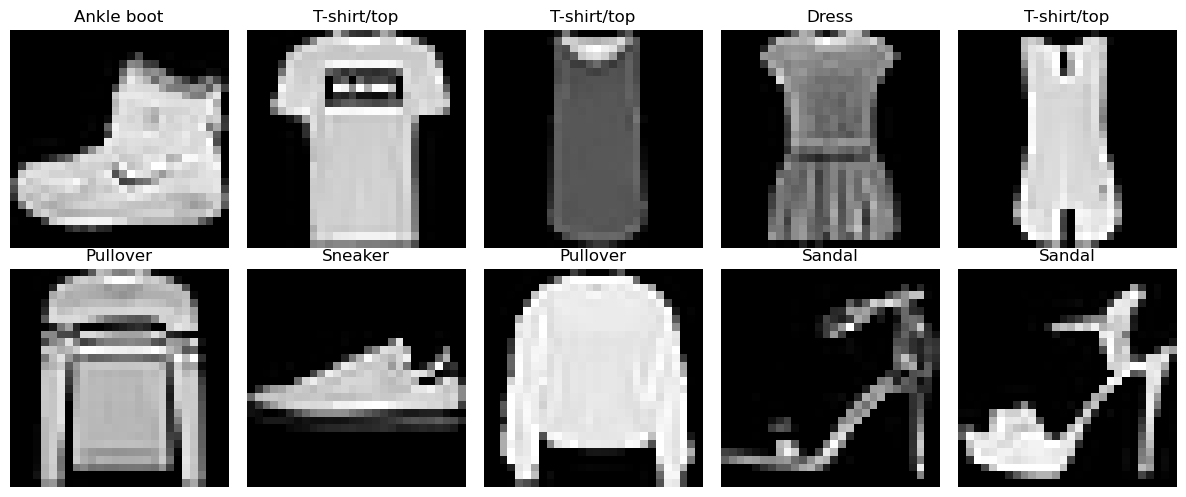

In [29]:
to_tensor = transforms.ToTensor()
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, i in zip(axes.flatten(), range(10)):
    img, label = raw_train[i]
    ax.imshow(to_tensor(img).squeeze(0).numpy(), cmap="gray")
    ax.set_title(class_names[label])
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Transforms and DataLoaders

`ToTensor()` puts pixels in `[0, 1]`. `Normalize((0.5,), (0.5,))` then maps them to `[-1, 1]`, which helps the optimizer converge. We add light **data augmentation** (horizontal flip + small rotation) to the training set only.

We split the training data into **80% train / 20% validation**. To avoid a common pitfall (where a `random_split` makes train and validation share one transform), we keep two views of the same data — one augmented, one plain — and select rows by index with `Subset`.


In [30]:
mean, std = (0.5,), (0.5,)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# Two views of the SAME training data
train_aug    = torchvision.datasets.FashionMNIST(root="./data", train=True,  download=True, transform=train_transform)
train_plain  = torchvision.datasets.FashionMNIST(root="./data", train=True,  download=True, transform=eval_transform)
test_dataset = torchvision.datasets.FashionMNIST(root="./data", train=False, download=True, transform=eval_transform)

g = torch.Generator().manual_seed(42)
perm = torch.randperm(len(train_aug), generator=g).tolist()
split = int(0.8 * len(perm))
train_idx, val_idx = perm[:split], perm[split:]

train_dataset = Subset(train_aug,   train_idx)   # augmented
val_dataset   = Subset(train_plain, val_idx)     # plain

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print("Train / Val / Test sizes:", len(train_dataset), len(val_dataset), len(test_dataset))
xb, yb = next(iter(train_loader))
print("Batch:", xb.shape, "| labels:", yb.shape)

Train / Val / Test sizes: 48000 12000 10000
Batch: torch.Size([64, 1, 28, 28]) | labels: torch.Size([64])


## 5. Define the CNN Architecture

Two convolutional blocks followed by two fully-connected layers:

- `conv1`: 1 -> 32 filters, 3x3, padding 1  (input is grayscale, so **in_channels = 1**)
- `conv2`: 32 -> 64 filters, 3x3, padding 1
- two `MaxPool2d(2, 2)` layers: 28 -> 14 -> 7
- flatten to `64 * 7 * 7 = 3136`, then `fc1` (3136 -> 512) and `fc2` (512 -> 10)
- a `Dropout` layer reduces overfitting

The `dropout` constructor argument is exposed on purpose so the GridSearch later can tune it.


In [31]:
class CNN(nn.Module):
    # Simple 2-conv CNN for 28x28 grayscale Fashion-MNIST (10 classes).
    def __init__(self, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)   # grayscale -> in_channels = 1
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(64 * 7 * 7, 512)   # 28 -> 14 -> 7
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # (B, 32, 14, 14)
        x = self.pool(torch.relu(self.conv2(x)))   # (B, 64, 7, 7)
        x = x.view(x.size(0), -1)                  # flatten -> 3136
        x = self.dropout(x)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN().to(device)
print(model)

# Quick shape sanity check
out = model(torch.randn(2, 1, 28, 28).to(device))
print("Output shape:", out.shape)   # expected (2, 10)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=3136, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)
Output shape: torch.Size([2, 10])


## 6. Counting the Parameters

For a conv layer: `params = (kH * kW * in_channels * out_channels) + out_channels` (the `+ out_channels` is the bias). For a linear layer: `params = (in_features * out_features) + out_features`.


In [32]:
def conv_params(out_ch, in_ch, k):
    return out_ch * in_ch * k * k + out_ch

conv1_p = conv_params(32, 1, 3)    # grayscale -> in_channels = 1
conv2_p = conv_params(64, 32, 3)
fc1_p   = 512 * (64 * 7 * 7) + 512
fc2_p   = 10 * 512 + 10
total   = conv1_p + conv2_p + fc1_p + fc2_p

print("Conv1:", conv1_p)
print("Conv2:", conv2_p)
print("FC1  :", fc1_p)
print("FC2  :", fc2_p)
print("Total:", total)
print("PyTorch count:", sum(p.numel() for p in model.parameters()))

Conv1: 320
Conv2: 18496
FC1  : 1606144
FC2  : 5130
Total: 1630090
PyTorch count: 1630090


## 7. Visualize Filters and Feature Maps (Before Training)

At initialization the filters are random, so the feature maps will not yet highlight meaningful structure. We will revisit these after training.


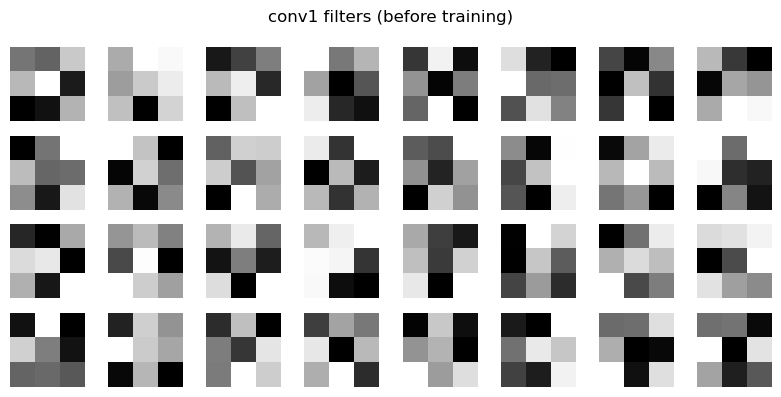

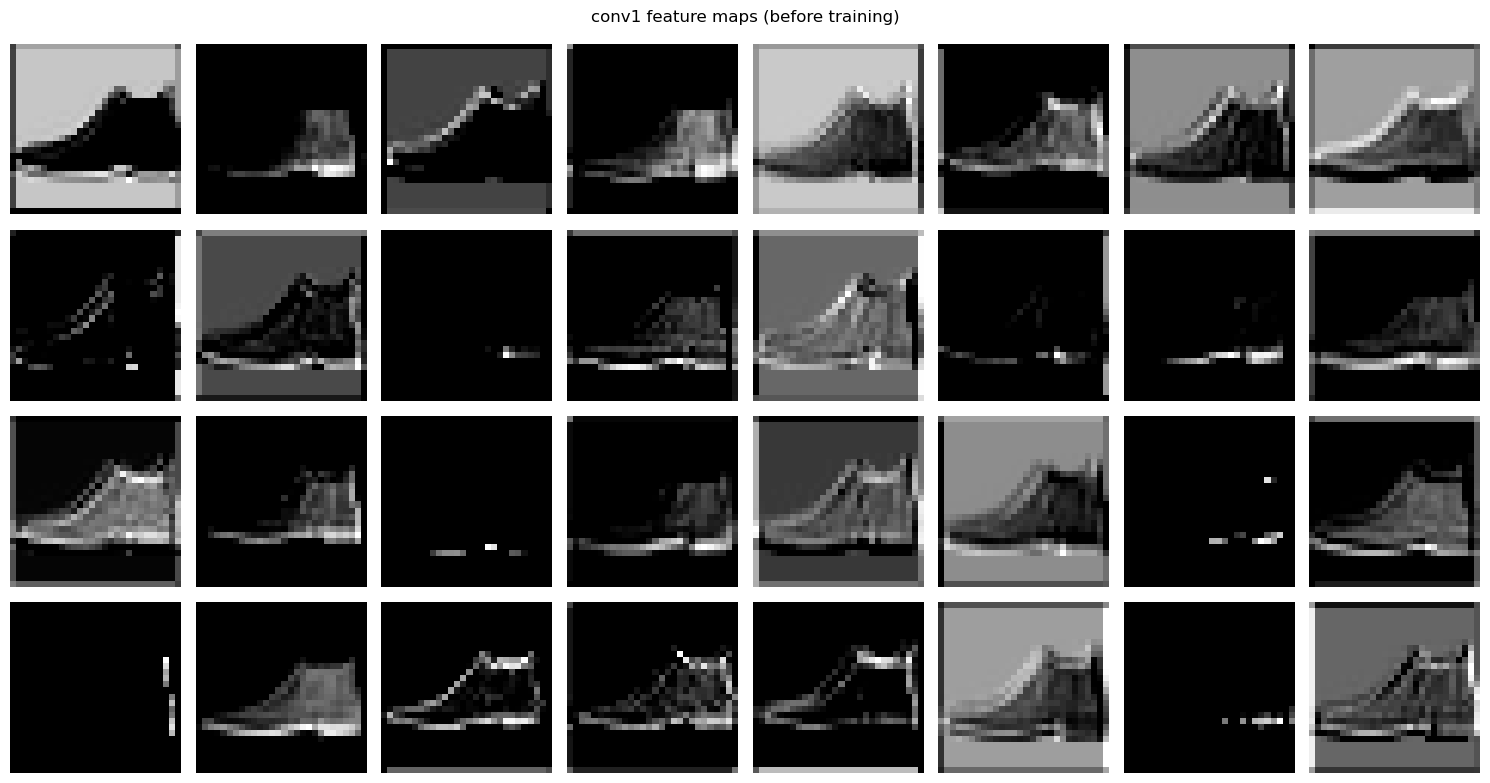

In [33]:
def visualize_filters(layer, title="Filters", n_columns=8):
    f = layer.weight.data.clone().cpu()
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)
    n = f.shape[0]
    n_rows = (n + n_columns - 1) // n_columns
    fig, axs = plt.subplots(n_rows, n_columns, figsize=(n_columns, n_rows))
    fig.suptitle(title)
    axs = np.array(axs).reshape(-1)
    for i in range(n):
        axs[i].imshow(f[i, 0], cmap="gray")   # first input channel
        axs[i].axis("off")
    for j in range(n, len(axs)):
        axs[j].axis("off")
    plt.tight_layout()
    plt.show()

def visualize_feature_maps(image, model, title="Feature maps (conv1)", n_columns=8):
    model.eval()
    with torch.no_grad():
        fmaps = torch.relu(model.conv1(image.unsqueeze(0).to(device))).squeeze(0).cpu()
    n = fmaps.shape[0]
    n_rows = (n + n_columns - 1) // n_columns
    fig, axs = plt.subplots(n_rows, n_columns, figsize=(15, 2 * n_rows))
    fig.suptitle(title)
    axs = np.array(axs).reshape(-1)
    for i in range(n):
        axs[i].imshow(fmaps[i], cmap="gray")
        axs[i].axis("off")
    for j in range(n, len(axs)):
        axs[j].axis("off")
    plt.tight_layout()
    plt.show()

sample_img, _ = test_dataset[0]
visualize_filters(model.conv1, title="conv1 filters (before training)")
visualize_feature_maps(sample_img, model, title="conv1 feature maps (before training)")

## 8. Train the Model

We train with Adam and cross-entropy loss, track training/validation metrics each epoch, and keep the weights from the best validation accuracy.


In [34]:
import copy
from tqdm import tqdm

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running, correct, total = 0.0, 0, 0
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total   += y.size(0)
    return running / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        running += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total   += y.size(0)
    return running / total, correct / total

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 12
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc, best_state = 0.0, copy.deepcopy(model.state_dict())

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc = evaluate(model, val_loader, criterion)
    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)
    print(f"Epoch {epoch:2d}/{epochs} | train_loss={tr_loss:.4f} acc={tr_acc:.4f} | val_loss={va_loss:.4f} acc={va_acc:.4f}")
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = copy.deepcopy(model.state_dict())

print("\nBest validation accuracy:", round(best_val_acc, 4))
model.load_state_dict(best_state)   # restore best weights

Epoch  1/12 | train_loss=0.5134 acc=0.8095 | val_loss=0.3561 acc=0.8677


Epoch  2/12 | train_loss=0.3564 acc=0.8673 | val_loss=0.3133 acc=0.8856


Epoch  3/12 | train_loss=0.3126 acc=0.8827 | val_loss=0.2685 acc=0.9034


Epoch  4/12 | train_loss=0.2802 acc=0.8942 | val_loss=0.2521 acc=0.9075


Epoch  5/12 | train_loss=0.2620 acc=0.9014 | val_loss=0.2603 acc=0.9042


...

Epoch  9/12 | train_loss=0.2119 acc=0.9204 | val_loss=0.2090 acc=0.9250


Epoch 10/12 | train_loss=0.2039 acc=0.9242 | val_loss=0.2134 acc=0.9247


Epoch 11/12 | train_loss=0.1965 acc=0.9269 | val_loss=0.2189 acc=0.9237


Epoch 12/12 | train_loss=0.1860 acc=0.9301 | val_loss=0.2132 acc=0.9243

Best validation accuracy: 0.925


<All keys matched successfully>

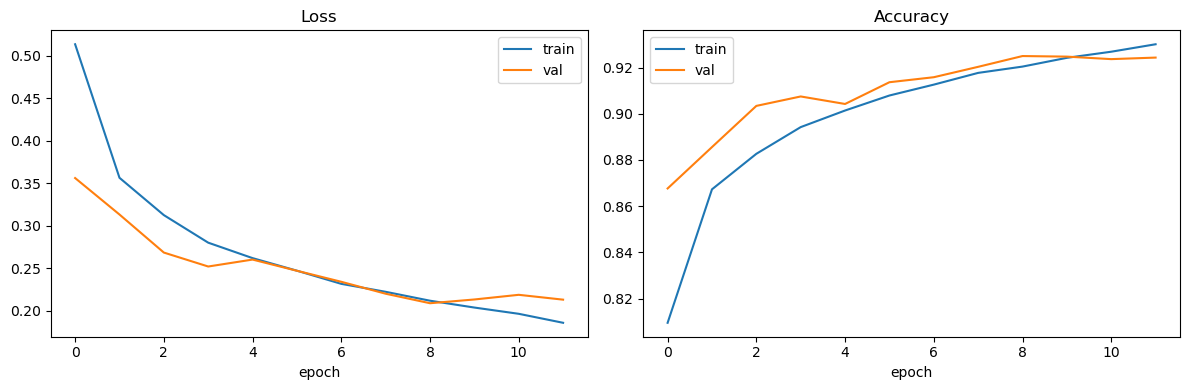

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history["train_acc"], label="train"); ax[1].plot(history["val_acc"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout()
plt.show()

## 9. Evaluate on the Test Set

In [36]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    ys, ps = [], []
    for x, y in loader:
        ps.append(model(x.to(device)).argmax(1).cpu().numpy())
        ys.append(y.numpy())
    return np.concatenate(ys), np.concatenate(ps)

y_true, y_pred = predict_all(model, test_loader)
print(f"Test accuracy: {(y_true == y_pred).mean() * 100:.2f}%\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Test accuracy: 91.72%

              precision    recall  f1-score   support

 T-shirt/top     0.8888    0.8310    0.8589      1000
     Trouser     0.9899    0.9840    0.9870      1000
    Pullover     0.8863    0.8650    0.8755      1000
       Dress     0.9274    0.9200    0.9237      1000
        Coat     0.8450    0.8940    0.8688      1000
      Sandal     0.9859    0.9770    0.9814      1000
       Shirt     0.7424    0.7810    0.7612      1000
     Sneaker     0.9548    0.9720    0.9633      1000
         Bag     0.9939    0.9830    0.9884      1000
  Ankle boot     0.9698    0.9650    0.9674      1000

    accuracy                         0.9172     10000
   macro avg     0.9184    0.9172    0.9176     10000
weighted avg     0.9184    0.9172    0.9176     10000



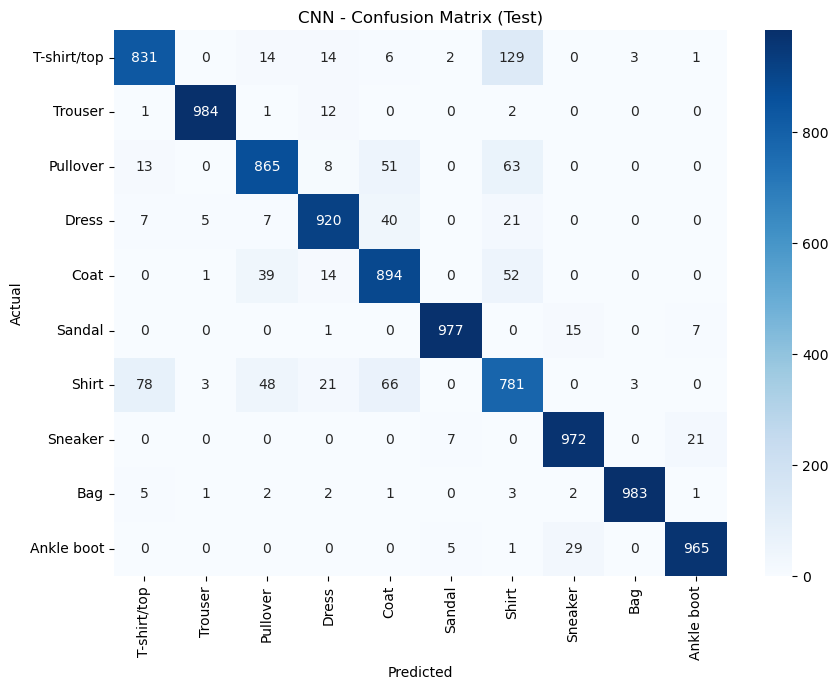

In [37]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("CNN - Confusion Matrix (Test)")
plt.tight_layout()
plt.show()

## 10. Visualize What the Trained Network Learned

After training, the first-layer filters tend to respond to simple structures such as edges and gradients, and the feature maps highlight where those patterns appear in the image.


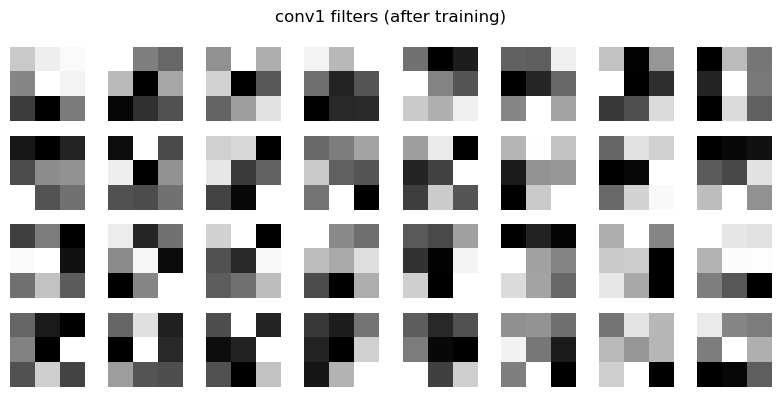

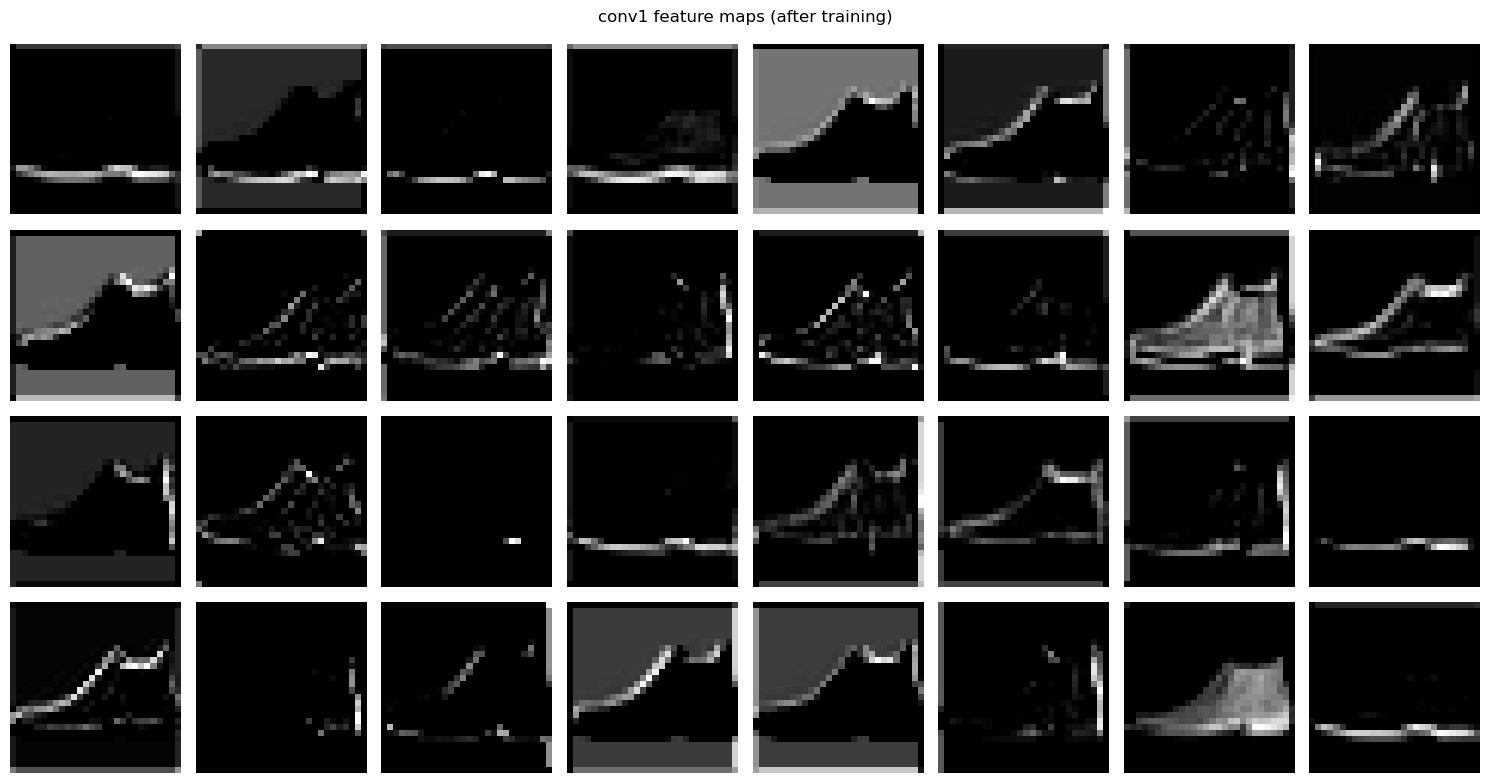

In [38]:
visualize_filters(model.conv1, title="conv1 filters (after training)")
visualize_feature_maps(sample_img, model, title="conv1 feature maps (after training)")

## 11. Hyperparameter Tuning with GridSearchCV (skorch)

`GridSearchCV` from scikit-learn does not understand PyTorch models directly, so we wrap our `CNN` with **skorch**'s `NeuralNetClassifier`. We search over a small grid on a subset of the data to keep runtime reasonable.

> This is slow on CPU. On Colab, enable a GPU runtime, or reduce `subset_size` / the grid.


In [39]:
from skorch import NeuralNetClassifier
from sklearn.model_selection import GridSearchCV

# Subset of the training data to keep the search fast
subset_size = 4000
X = np.stack([train_plain[i][0].numpy() for i in range(subset_size)]).astype(np.float32)
y = np.array([train_plain[i][1] for i in range(subset_size)]).astype(np.int64)

net = NeuralNetClassifier(
    CNN,
    criterion=nn.CrossEntropyLoss,
    optimizer=optim.Adam,
    batch_size=64,
    max_epochs=5,
    verbose=0,
    device=("cuda" if torch.cuda.is_available() else "cpu"),
)

params = {
    "lr": [1e-2, 1e-3],
    "max_epochs": [5, 10],
    "module__dropout": [0.3, 0.5],            # tunes the CNN's dropout argument
    "optimizer__weight_decay": [0.0, 1e-4],
}

gs = GridSearchCV(net, params, refit=True, cv=3, scoring="accuracy", verbose=2)
gs.fit(X, y)

print("\nBest CV score:", round(gs.best_score_, 4))
print("Best params  :", gs.best_params_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END lr=0.01, max_epochs=5, module__dropout=0.3, optimizer__weight_decay=0.0; total time=   1.3s
[CV] END lr=0.01, max_epochs=5, module__dropout=0.3, optimizer__weight_decay=0.0; total time=   1.1s
[CV] END lr=0.01, max_epochs=5, module__dropout=0.3, optimizer__weight_decay=0.0; total time=   1.1s
[CV] END lr=0.01, max_epochs=5, module__dropout=0.3, optimizer__weight_decay=0.0001; total time=   1.1s
[CV] END lr=0.01, max_epochs=5, module__dropout=0.3, optimizer__weight_decay=0.0001; total time=   1.3s
[CV] END lr=0.01, max_epochs=5, module__dropout=0.3, optimizer__weight_decay=0.0001; total time=   1.3s
[CV] END lr=0.01, max_epochs=5, module__dropout=0.5, optimizer__weight_decay=0.0; total time=   1.1s
[CV] END lr=0.01, max_epochs=5, module__dropout=0.5, optimizer__weight_decay=0.0; total time=   1.1s
[CV] END lr=0.01, max_epochs=5, module__dropout=0.5, optimizer__weight_decay=0.0; total time=   1.1s
[CV] END lr=0.01, max

## 12. Save the Trained Model (link to Assignment 5)

We save the **best full-data model** (from section 8) as `cnn_best.pt`. Assignment 5 will load this exact architecture and these weights to compare the custom CNN against ResNet18 transfer learning.

> Download `cnn_best.pt` from this environment and upload it into the Assignment 5 notebook's working directory.


In [40]:
torch.save(model.state_dict(), "cnn_best.pt")
print("Saved trained CNN to cnn_best.pt")
print("Architecture: CNN(conv1=1->32, conv2=32->64, fc1=3136->512, fc2=512->10)")

Saved trained CNN to cnn_best.pt
Architecture: CNN(conv1=1->32, conv2=32->64, fc1=3136->512, fc2=512->10)


In [41]:
import os
print(os.getcwd())

C:\Users\liory\Downloads\Deep_Learning_Course_git\Homework_04_CNN_Fashion_MNIST
